In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Correct the file path
file_path = 'Excel_data/Filling_Mean_STD - Copy.csv'
# file_path = 'Filling_Mean_Pulsatile.csv'
# Read the CSV file without headers
data = pd.read_csv(file_path, header=None)

In [229]:
data.columns = ['Index', 'Column1', 'Column2', 'Column3', 'Column4', 'Column5']

# If you know which columns are 'x' and 'y', rename them accordingly:
# For example, if 'Column1' is x and 'Column2' is y:
data.columns = ['Index', 'Mean', 'StdDev', 'Other1', 'Other2', 'Other3']

# Check the columns to confirm they're correct
print(data.columns)  # This will help you ensure the columns are renamed

Index(['Index', 'Mean', 'StdDev', 'Other1', 'Other2', 'Other3'], dtype='object')


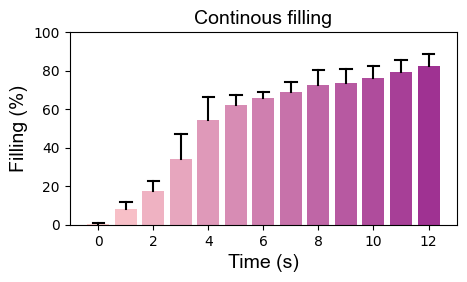

In [235]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

num_colors = 16
# Define the colormap from light blue to dark green
colormap = mcolors.LinearSegmentedColormap.from_list('red', [(1, 0.8, 0.8), (0.5, 0, 0.5)])

# Normalize the data
max_value = max(data['Mean'])
normalized_mean = (data['Mean'] / (max_value+100000)) * 100
normalized_stddev = (data['StdDev'] / (max_value+100000)) * 100

# Generate the gradient of colors
colors = [colormap(i / num_colors) for i in range(num_colors)]

# Plot the bar chart with the updated colors
plt.figure(figsize=(5, 2.5))
# Plot the bar chart with the updated colors
# plt.grid(True, alpha=0.2, zorder=0,linestyle='-')
# plt.bar(data['Index'][::1], normalized_mean[::1], yerr=normalized_stddev[::1], capsize=5, color=colors, width=4)# , edgecolor='black'
# bars = plt.bar(data['Index'], normalized_mean, color=colors, width=4, edgecolor='black')

# # Add error bars on top only
# # Specifying yerr with upper limits only
# upper_limits = normalized_stddev
# lower_limits = [0] * len(normalized_stddev)  # No lower error
# plt.errorbar(data['Index'], normalized_mean, yerr=[lower_limits, upper_limits], fmt=' ', capsize=5, ecolor='black')

bars = plt.bar(data['Index'], normalized_mean, color=colors, width=0.8)

# Manually add error bars with caps on top only
capsize = 1.5  # size of the error bar cap in points
capwidth = capsize / 72. * plt.gcf().dpi / plt.gcf().get_size_inches()[0]  # convert points to figure coordinates

for i, (x, mean, error) in enumerate(zip(data['Index'], normalized_mean, normalized_stddev)):
    # Draw the error bars
    plt.plot([x, x], [mean, mean + error], color='black')  # Vertical line for error
    
    # Draw the cap
    plt.plot([x - capwidth / 2, x + capwidth / 2], [mean + error, mean + error], color='black')  # Horizontal line for cap

# Adding labels and title
plt.xlabel('Time (s)', fontname='Arial', fontsize=14)
plt.ylabel('Filling (%)', fontname='Arial', fontsize=14)
# plt.title('Pulsatile filling', fontname='Arial', fontsize=14)
plt.title('Continous filling', fontname='Arial', fontsize=14)
plt.ylim(0, 100)
plt.savefig('figure.png', dpi=300,bbox_inches='tight')

# Show plot
plt.show()



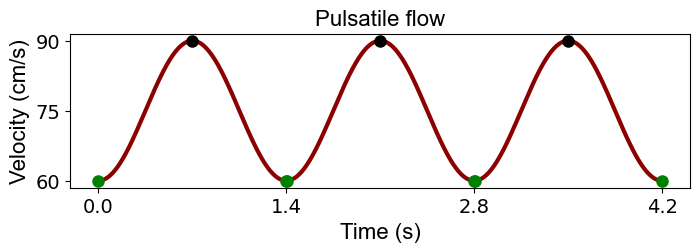

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the sine wave
min_val = 60
max_val = 90
mid = (max_val + min_val) / 2
amplitude = (max_val - min_val) / 2
period = 1.4  # period of the sine wave in seconds
frequency = 1 / period  # frequency of the sine wave

# Time array from 0 to 2.8 seconds (to show a few cycles)
t = np.linspace(0, 4.2, 1000)

# Adjust sine wave calculation to match the frequency
# Adding a phase shift of -π/2 to start the wave from the minimum
y = mid + amplitude * np.sin(2 * np.pi * frequency * t - np.pi / 2)

# Set up figure and axes
fig, ax = plt.subplots(figsize=(8,2))

# Plot the sine wave with improved style
ax.plot(t, y, color='darkred', linestyle='-', linewidth=3)

# Set x and y axis labels
ax.set_xlabel('Time (s)', fontsize=16, fontname='Arial')
ax.set_ylabel('Velocity (cm/s)', fontsize=16, fontname='Arial')

# Set plot title
ax.set_title('Pulsatile flow', fontsize=16, fontname='Arial')

# Set grid lines
# ax.grid(True, linestyle='--', alpha=1)

# Function to detect minima and maxima
def detect_minima(y):
    indices = np.argwhere((np.roll(y, 3) > y) & (np.roll(y, -2) > y))
    return indices.flatten()

def detect_maxima(y):
    indices = np.argwhere((np.roll(y, 1) < y) & (np.roll(y, -2) < y))
    return indices.flatten()

min_indices = detect_minima(y)
max_indices = detect_maxima(y)

# Highlight minima
for index in min_indices:
    ax.plot(t[index], y[index], 'o', color='green', markersize=8)  # Mark minimum points

# Highlight maxima
for index in max_indices:
    ax.plot(t[index], y[index], 'o', color='black', markersize=8)  # Mark maximum points

# Set the x-axis ticks
ax.set_xticks(np.arange(0, 4.3, 1.4))  # x-ticks from 0 to 2.8 every 0.7
ax.set_yticks(np.arange(60, 91, 15))  # y-ticks from 60 to 90 every 10
ax.tick_params(axis='y', labelsize=14) 
ax.tick_params(axis='x', labelsize=14) # Increase y-tick font size
# Show the plot
plt.savefig('Pulsatile_velocity', dpi=300,bbox_inches='tight')
plt.show()






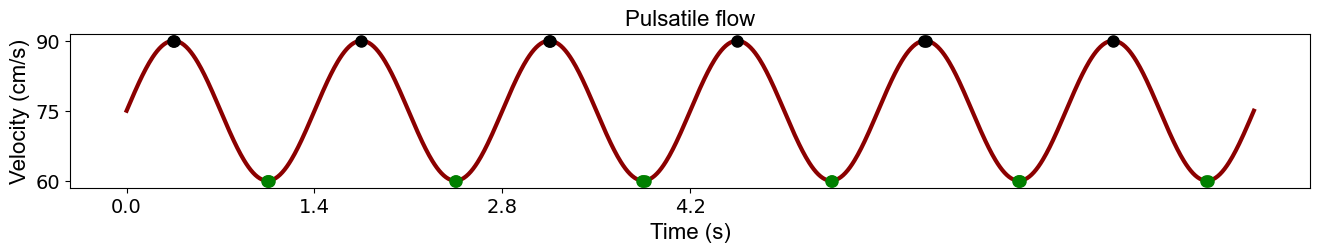

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the sine wave
min_val = 60
max_val = 90
mid = (max_val + min_val) / 2
amplitude = (max_val - min_val) / 2
period = 1.4  # period of the sine wave in seconds
frequency = 1 / period  # frequency of the sine wave

# Time array from 0 to 4.2 seconds (to show a few cycles)
t = np.linspace(0, 8.4, 1000)

# Adjust sine wave calculation to match the frequency
# No phase shift to start the wave from the center
y = mid + amplitude * np.sin(2 * np.pi * frequency * t)

# Set up figure and axes
fig, ax = plt.subplots(figsize=(16, 2))

# Plot the sine wave with improved style
ax.plot(t, y, color='darkred', linestyle='-', linewidth=3)

# Set x and y axis labels
ax.set_xlabel('Time (s)', fontsize=16, fontname='Arial')
ax.set_ylabel('Velocity (cm/s)', fontsize=16, fontname='Arial')

# Set plot title
ax.set_title('Pulsatile flow', fontsize=16, fontname='Arial')

# Function to detect minima and maxima
def detect_minima(y):
    indices = np.argwhere((np.roll(y, 3) > y) & (np.roll(y, -2) > y))
    return indices.flatten()

def detect_maxima(y):
    indices = np.argwhere((np.roll(y, 1) < y) & (np.roll(y, -2) < y))
    return indices.flatten()

min_indices = detect_minima(y)
max_indices = detect_maxima(y)

# Highlight minima
for index in min_indices:
    ax.plot(t[index], y[index], 'o', color='green', markersize=8)  # Mark minimum points

# Highlight maxima
for index in max_indices:
    ax.plot(t[index], y[index], 'o', color='black', markersize=8)  # Mark maximum points

# Set the x-axis ticks
ax.set_xticks(np.arange(0, 4.3, 1.4))  # x-ticks from 0 to 4.2 every 1.4
ax.set_yticks(np.arange(60, 91, 15))  # y-ticks from 60 to 90 every 15
ax.tick_params(axis='y', labelsize=14) 
ax.tick_params(axis='x', labelsize=14)

# Save and show the plot
plt.savefig('ON_OFF_US', dpi=300, bbox_inches='tight')
plt.show()


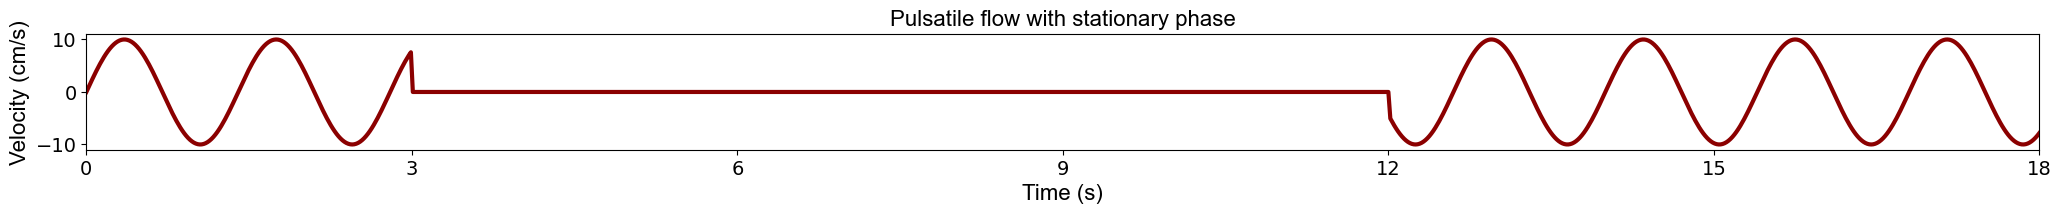

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for the sine wave
min_val = -10
max_val = 10
mid = (max_val + min_val) / 2
amplitude = (max_val - min_val) / 2
period = 1.4  # period of the sine wave in seconds
frequency = 1 / period  # frequency of the sine wave

# Time array from 0 to 8.4 seconds
t = np.linspace(0, 18, 1000)

# Sine wave calculation to match the frequency
y_sine1 = mid + amplitude * np.sin(2 * np.pi * frequency * t[t < 3])
y_flat = np.full(len(t[(t >= 3) & (t <= 12)]), mid)  # Flat section at midpoint level
y_sine2 = mid + amplitude * np.sin(2 * np.pi * frequency * t[t > 12])

# Combine all sections
y = np.concatenate((y_sine1, y_flat, y_sine2))

# Set up figure and axes
fig, ax = plt.subplots(figsize=(25.2, 1.5))

# Plot the combined wave
ax.plot(t, y, color='darkred', linestyle='-', linewidth=3)

# Set x and y axis labels
ax.set_xlabel('Time (s)', fontsize=16, fontname='Arial')
ax.set_ylabel('Velocity (cm/s)', fontsize=16, fontname='Arial')

# Set plot title
ax.set_title('Pulsatile flow with stationary phase', fontsize=16, fontname='Arial')
ax.set_xlim(0, 18)

# Set the x-axis and y-axis ticks
ax.set_xticks(np.arange(0, 19, 3))  # x-ticks to reflect all segments
ax.set_yticks(np.arange(-10, 11, 10))  # y-ticks from 60 to 90 every 15
ax.tick_params(axis='y', labelsize=14)
ax.tick_params(axis='x', labelsize=14)

# Save and show the plot
plt.savefig('ON_OFF_US', dpi=300, bbox_inches='tight')
plt.show()

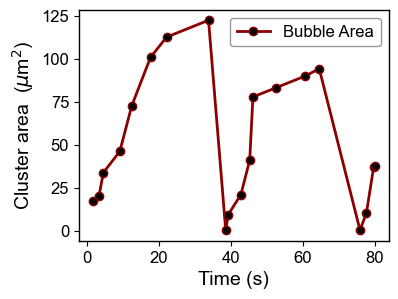

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Set the font globally
rcParams['font.family'] = 'Arial'
rcParams['font.size'] = 12

# Read data from CSV file
data1 = pd.read_csv('Excel_data/Bubble_shooting.csv')
data1.columns = ['A', 'B']  # Correctly labeled columns as 'A' for time and 'B' for bubble area

# Extract the time and bubble area columns
time = data1['A']
bubble_area = data1['B']

# Plot the data
plt.figure(figsize=(4, 3), facecolor='white')  # Ensure white background for the figure
plt.plot(time, bubble_area, label='Bubble Area', marker='o', linestyle='-', color='darkred', linewidth=2, markerfacecolor='black', markersize=6)

# Set the x-axis label with enhanced formatting
plt.xlabel('Time (s)', fontsize=14, backgroundcolor='white')

# Set the y-axis label with enhanced formatting
plt.ylabel('Cluster area  ($\mu$m$^2$)', fontsize=14, backgroundcolor='white')

# Set the size of the tick labels on both axes
plt.tick_params(axis='both', which='major', labelsize=12)

# Darken the box around the plot
plt.gca().spines['top'].set_linewidth(1)
plt.gca().spines['top'].set_color('black')
plt.gca().spines['right'].set_linewidth(1)
plt.gca().spines['right'].set_color('black')
plt.gca().spines['left'].set_linewidth(1)
plt.gca().spines['left'].set_color('black')
plt.gca().spines['bottom'].set_linewidth(1)
plt.gca().spines['bottom'].set_color('black')

# Add the legend with a clean background
plt.legend(facecolor='white', framealpha=0.4, edgecolor='black')

# Turn off the grid
plt.grid(False)

# Save the plot with high resolution and tight bounding box
plt.savefig('Bubble_shooting', dpi=300, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()






C:\Users\mmabo\AppData\Local\Temp\ipykernel_19684\2362276178.py:23: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  plt.errorbar(x=df['Distance'], y=df['Velocity'], yerr=df['StdDev'], fmt='-o', capsize=5, ecolor='lightblue', elinewidth=2,
C:\Users\mmabo\AppData\Local\Temp\ipykernel_19684\2362276178.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(x=df['Distance'], y=df['Velocity'], yerr=df['StdDev'], fmt='-o', capsize=5, ecolor='lightblue', elinewidth=2,


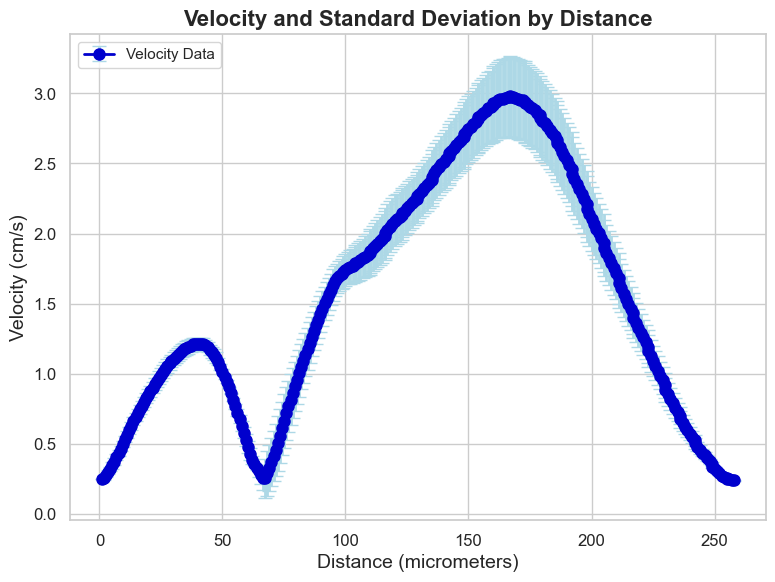

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv('Excel_data/PIV_Velocity_Vortex_center.csv')
df.columns = ['Distance', 'Velocity', 'StdDev']

# Convert Distance from meters to micrometers
df['Distance'] = df['Distance'] * 1_000_000  # 1 meter = 1,000,000 micrometers

# Convert Velocity from m/s to mm/s
df['Velocity'] = df['Velocity'] * 1_00  # 1 m/s = 1,00 cm/s

# Convert Standard Deviation from m/s to mm/s
df['StdDev'] = df['StdDev'] * 1_00  # scaling standard deviation

# Set the seaborn style
sns.set(style="whitegrid")

# Create the plot using Matplotlib directly for handling the error bars
plt.figure(figsize=(12, 6))
plt.errorbar(x=df['Distance'], y=df['Velocity'], yerr=df['StdDev'], fmt='-o', capsize=5, ecolor='lightblue', elinewidth=2, 
             marker='o', markersize=8, color='mediumblue', linestyle='-', linewidth=2, label='Velocity Data')

# Add titles and labels with improved formatting
plt.title('Velocity and Standard Deviation by Distance', fontsize=16, fontweight='bold')
plt.xlabel('Distance (micrometers)', fontsize=14)
plt.ylabel('Velocity (cm/s)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='upper left')

# Show the plot
plt.show()


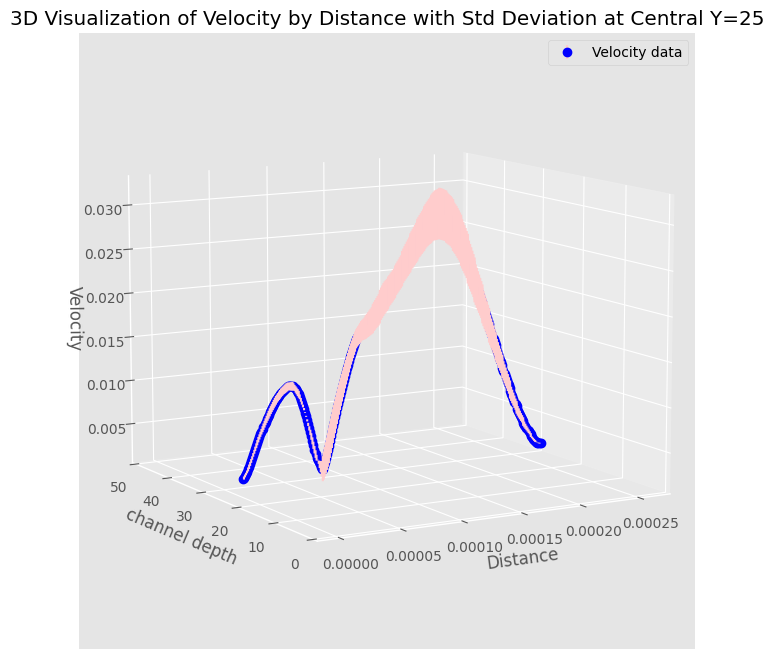

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Read the CSV file
df = pd.read_csv('Excel_data/PIV_Velocity_Vortex_center.csv')
df.columns = ['Distance', 'Velocity', 'StdDev']

# Set up the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Data for plotting
distance = df['Distance']
velocity = df['Velocity']
std_dev = df['StdDev']

# Plotting points with error bars along the z-axis (Velocity)
for i in range(len(distance)):
    # Plotting each point and its standard deviation
    ax.errorbar(distance[i], 25, velocity[i], zerr=std_dev[i], fmt='o', color='blue', ecolor=(1, 0.8, 0.8), label='Velocity data' if i == 0 else "")

# Labeling
ax.set_xlabel('Distance')
ax.set_ylabel('channel depth')
ax.set_zlabel('Velocity')

# Set Y-axis limits to represent the span from 0 to 50
ax.set_ylim([0, 50])

# Title and legend
ax.set_title('3D Visualization of Velocity by Distance with Std Deviation at Central Y=25')
ax.legend()

# Set the view angle for better viewing perspective
ax.view_init(elev=10, azim=240)  # Adjust these angles as needed to get the best view

# Show the plot
plt.show()
